In [271]:
import warnings
warnings.filterwarnings('ignore')

import pandas as P
import numpy as N
import matplotlib.pyplot as PLOT
import seaborn as SEA

In [272]:
D = P.read_csv ("TV.csv")

In [273]:
print(D.shape)

(52966, 15)


In [274]:
print(D.dtypes)

stop_date              object
stop_time              object
country_name          float64
driver_gender          object
driver_age_raw        float64
driver_age            float64
driver_race            object
violation_raw          object
violation              object
search_conducted       object
search_type            object
stop_outcome           object
is_arrested            object
stop_duration          object
drugs_related_stop     object
dtype: object


In [275]:
D["driver_age"] = P.to_numeric(D["driver_age"], errors='coerce')

In [276]:
SDF = D[D["violation"] == "Speeding"].copy ()
print(len(D))
print(len(SDF))
print((len(D)/len(SDF)) * 100 , "%")

52966
32139
164.80288745760603 %


In [277]:
print(D.columns)

Index(['stop_date', 'stop_time', 'country_name', 'driver_gender',
       'driver_age_raw', 'driver_age', 'driver_race', 'violation_raw',
       'violation', 'search_conducted', 'search_type', 'stop_outcome',
       'is_arrested', 'stop_duration', 'drugs_related_stop'],
      dtype='object')


In [278]:
GC = SDF["driver_gender"].value_counts(normalize = True) * 100
print(GC.round(2))

driver_gender
M    69.15
F    30.85
Name: proportion, dtype: float64


In [279]:
RD = SDF["driver_race"].value_counts(normalize = True) * 100
print(RD.round(2))

driver_race
White       81.51
Black        9.72
Hispanic     5.27
Asian        3.22
Other        0.28
Name: proportion, dtype: float64


In [280]:
OC = SDF["stop_outcome"].value_counts(normalize = True) * 100
print(RD.round (2))

driver_race
White       81.51
Black        9.72
Hispanic     5.27
Asian        3.22
Other        0.28
Name: proportion, dtype: float64


In [281]:
SR = (SDF["search_conducted"] == True).mean() * 100
DR = (SDF["drugs_related_stop"] == True).mean() * 100
print(SR , "%")
print(DR , "%")

2.1655932045178754 %
0.45116525094122406 %


In [282]:
SDF["stop_date"] = P.to_datetime(SDF["stop_date"], format='%m/%d/%Y', errors='coerce')
SDF["month"] = SDF["stop_date"].dt.month
MC = SDF["month"].value_counts().sort_index()
print(MC)

month
1     3146
2     2451
3     2660
4     2676
5     2857
6     2722
7     2516
8     2482
9     2555
10    2733
11    2951
12    2390
Name: count, dtype: int64


In [283]:
def extract_hour(time_str):
    try:
        return datetime.strptime(time_str, '%H:%M').hour
    except:
        return None

SDF["hour"] = SDF["stop_time"].apply(extract_hour)
HC = SDF["hour"].value_counts().sort_index()
print(HC.head(5))


Series([], Name: count, dtype: int64)


In [284]:
SDF["day_of_week"] = SDF["stop_date"].dt.day_name()
DC = SDF["day_of_week"].value_counts()
print(DC)

day_of_week
Saturday     5115
Sunday       4916
Monday       4602
Tuesday      4499
Wednesday    4412
Friday       4355
Thursday     4240
Name: count, dtype: int64


In [285]:
DRC = SDF["stop_duration"].value_counts(normalize=True) * 100
print(DRC.round(2))

stop_duration
0-15 Min     81.96
16-30 Min    16.63
30+ Min       1.41
Name: proportion, dtype: float64


In [286]:
AS = (SDF["is_arrested"] == True).mean() * 100
NS = D[D["violation"] != "Speeding"]
ANS = (NS["is_arrested"] == True).mean() * 100
print(AS , "%")
print(ANS , "%")

1.5215159152431625 %
6.626014308349738 %


In [287]:
PLOT.figure(figsize=(14, 10))


<Figure size 1400x1000 with 0 Axes>

<Figure size 1400x1000 with 0 Axes>

Text(0, 0.5, 'Count')

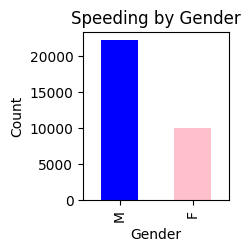

In [288]:
PLOT.subplot(2, 3, 1)
SDF["driver_gender"].value_counts().plot(kind = "bar", color = ["blue" , "pink"])
PLOT.title("Speeding by Gender")
PLOT.xlabel("Gender")
PLOT.ylabel("Count")


Text(0, 0.5, 'Count')

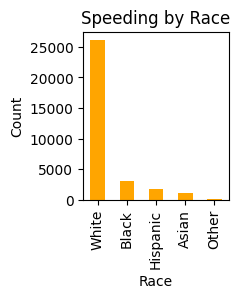

In [289]:
PLOT.subplot(2, 3, 2)
SDF["driver_race"].value_counts().plot(kind = "bar" , color = "orange")
PLOT.title("Speeding by Race")
PLOT.xlabel('Race')
PLOT.ylabel("Count")

Text(0, 0.5, 'Count')

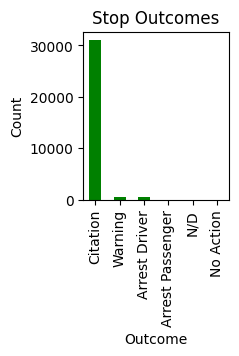

In [290]:
PLOT.subplot(2, 3, 3)
SDF["stop_outcome"].value_counts().plot(kind = "bar" , color = "green")
PLOT.title("Stop Outcomes")
PLOT.xlabel("Outcome")
PLOT.ylabel("Count")

Text(0, 0.5, 'Count')

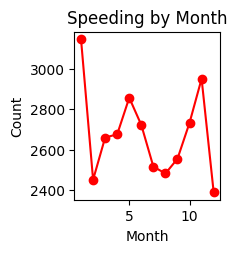

In [291]:
PLOT.subplot(2, 3, 4)
MC.plot(kind = "line" , marker = "o" , color = "red")
PLOT.title("Speeding by Month")
PLOT.xlabel("Month")
PLOT.ylabel("Count")

Text(0, 0.5, 'Count')

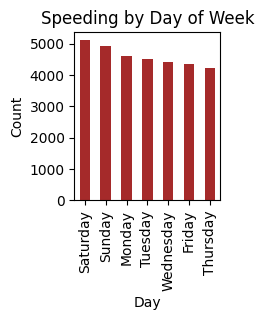

In [292]:
PLOT.subplot(2, 3, 6)
DC.plot(kind = "bar" , color = "brown")
PLOT.title("Speeding by Day of Week")
PLOT.xlabel('Day')
PLOT.ylabel('Count')


In [293]:
PLOT.tight_layout()
PLOT.show()

<Figure size 640x480 with 0 Axes>

In [294]:
print("Speeding by age (Top 10 ages):")
print(SDF["driver_age"].value_counts().head(10))

Speeding by age (Top 10 ages):
driver_age
21.0    1670
20.0    1648
22.0    1609
19.0    1473
23.0    1472
24.0    1437
25.0    1278
26.0    1181
27.0    1075
28.0    1055
Name: count, dtype: int64
